In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
# Required imports
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import hashlib
import os
import cv2

In [3]:
# Set base dir for dataset
base_dir='/kaggle/input/competitions/cassava-leaf-disease-classification'

In [4]:
with open('/kaggle/input/competitions/cassava-leaf-disease-classification/label_num_to_disease_map.json') as file:
    print('yes')

yes


In [5]:
# Step 1 : Load and inspect label map (mapping from numerical labels to disease names):
with open(os.path.join(base_dir,'label_num_to_disease_map.json')) as file:
    map_classes=json.loads(file.read())
    map_classes={int(k): v for k, v in map_classes.items()}

# Display the mapping
print('Class Mapping:')
print(json.dumps(map_classes,indent=4))

Class Mapping:
{
    "0": "Cassava Bacterial Blight (CBB)",
    "1": "Cassava Brown Streak Disease (CBSD)",
    "2": "Cassava Green Mottle (CGM)",
    "3": "Cassava Mosaic Disease (CMD)",
    "4": "Healthy"
}


In [6]:
os.listdir(os.path.join(base_dir,'train_images'))

['1235188286.jpg',
 '1215607589.jpg',
 '478554372.jpg',
 '2763304605.jpg',
 '2826122413.jpg',
 '111117998.jpg',
 '231268038.jpg',
 '4201965605.jpg',
 '3224710052.jpg',
 '1290729293.jpg',
 '1578977008.jpg',
 '2530575673.jpg',
 '720275537.jpg',
 '3459977804.jpg',
 '1258625916.jpg',
 '2174460518.jpg',
 '4054194563.jpg',
 '3977938536.jpg',
 '1118493919.jpg',
 '719168391.jpg',
 '1058931181.jpg',
 '188217517.jpg',
 '3709602808.jpg',
 '3775318400.jpg',
 '1403091423.jpg',
 '2569050922.jpg',
 '3973452259.jpg',
 '2869286599.jpg',
 '3986994681.jpg',
 '1671511517.jpg',
 '3823683287.jpg',
 '75068408.jpg',
 '950677455.jpg',
 '3567679401.jpg',
 '688489193.jpg',
 '3571106948.jpg',
 '2885564001.jpg',
 '2317789476.jpg',
 '1031772206.jpg',
 '23975111.jpg',
 '823914480.jpg',
 '852377476.jpg',
 '3492042850.jpg',
 '1338159402.jpg',
 '1230974910.jpg',
 '2590675849.jpg',
 '2329535405.jpg',
 '3043785326.jpg',
 '2709529150.jpg',
 '329174765.jpg',
 '3439578627.jpg',
 '1201098987.jpg',
 '4146910494.jpg',
 '337780

In [7]:
# Step:2 Load training image filenames and display the count
input_files=os.listdir(os.path.join(base_dir,'train_images'))
print(f'Number of train images : {len(input_files)}')

Number of train images : 21397


In [8]:
# Step:3 Load train.csv and add a human-readable class name based on the mapping
df_train=pd.read_csv(os.path.join(base_dir,'train.csv'))
df_train.head()

,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


In [10]:
df_train['class_name']=df_train['label'].map(map_classes)
df_train

,image_id,label,class_name
0,1000015157.jpg,0,Cassava Bacterial Blight (CBB)
1,1000201771.jpg,3,Cassava Mosaic Disease (CMD)
2,100042118.jpg,1,Cassava Brown Streak Disease (CBSD)
3,1000723321.jpg,1,Cassava Brown Streak Disease (CBSD)
4,1000812911.jpg,3,Cassava Mosaic Disease (CMD)
...,...,...,...
21392,999068805.jpg,3,Cassava Mosaic Disease (CMD)
21393,999329392.jpg,3,Cassava Mosaic Disease (CMD)
21394,999474432.jpg,1,Cassava Brown Streak Disease (CBSD)
21395,999616605.jpg,4,Healthy


In [11]:
df_train['class_name'].value_counts()

class_name
Cassava Mosaic Disease (CMD)           13158
Healthy                                 2577
Cassava Green Mottle (CGM)              2386
Cassava Brown Streak Disease (CBSD)     2189
Cassava Bacterial Blight (CBB)          1087
Name: count, dtype: int64

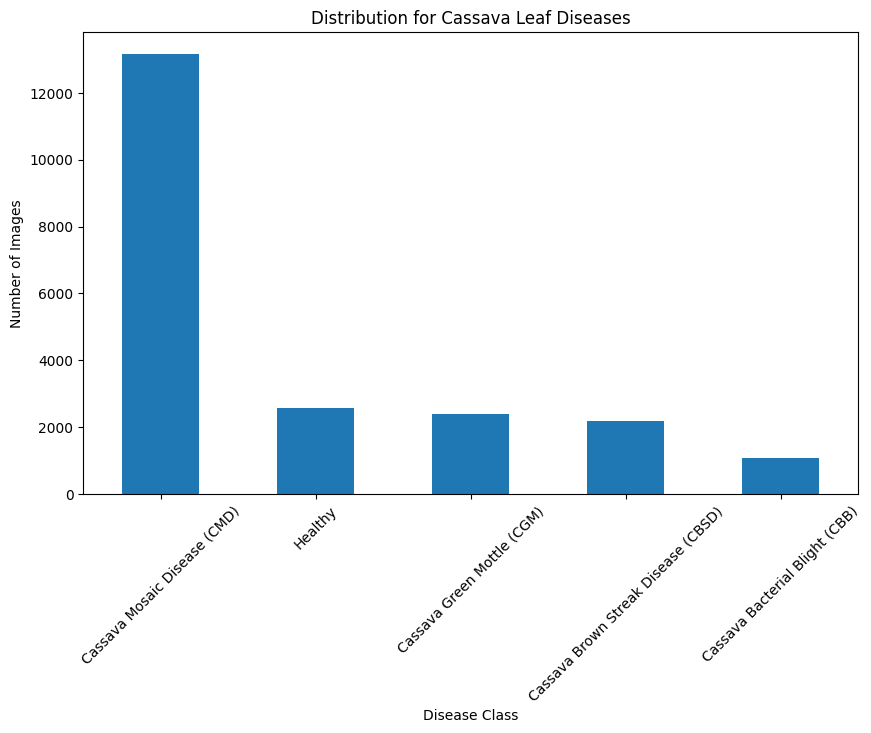

In [13]:
# Step:4 Check class distribution
# Distribution plot
dist=df_train['class_name'].value_counts()
plt.figure(figsize=(10,6))
dist.plot(kind='bar')
plt.title('Distribution for Cassava Leaf Disease')
plt.xlabel('Disease Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.show()

If we are using transfer learning.
Then no worry for imbalance data it will handle internally

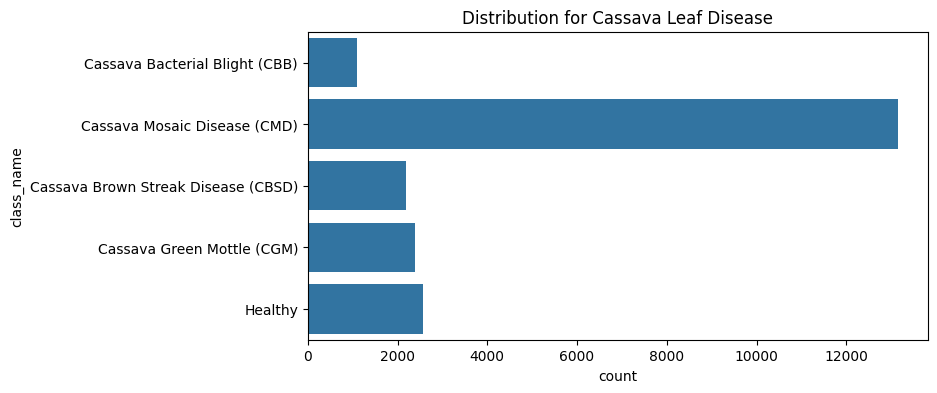

In [21]:
plt.figure(figsize=(8,4))
sns.countplot(y='class_name',data=df_train)
plt.title('Distribution for Cassava Leaf Disease')
plt.show()

In [18]:
# Step:5 Basic Dataset exploration
# Show data info and summary statistics
print('Dataset Info:')
print(df_train.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21397 entries, 0 to 21396
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_id    21397 non-null  object
 1   label       21397 non-null  int64 
 2   class_name  21397 non-null  object
dtypes: int64(1), object(2)
memory usage: 501.6+ KB
None


In [19]:
print('\nDataset Summary Statistics:')
print(df_train.describe())


Dataset Summary Statistics:
              label
count  21397.000000
mean       2.651914
std        0.988565
min        0.000000
25%        2.000000
50%        3.000000
75%        3.000000
max        4.000000


In [20]:
# Step:6 Check for missing values and duplicates
print(f'\nMissing values in each column:\n{df_train.isnull().sum()}')
print(f'Number of duplicate rows:{df_train.duplicated().sum()}')


Missing values in each column:
image_id      0
label         0
class_name    0
dtype: int64
Number of duplicate rows:0


Images->
let's check the shape of the images.

Images-50 * 50  very small pixels
it doesn't make any sense to upscale to 224*224 (mess up information)


images 600*600

resize to may be 224 * 224
500*500 
image size distribution need to tune resize image size

In [25]:
# Step:7 Analyze image shapes (size dimensions) for a sample of 300 images
# Dictionary to store image shapes and their counts
img_shapes={}
for image_name in os.listdir(os.path.join(base_dir,'train_images'))[:1000]:
    image=cv2.imread(os.path.join(base_dir,'train_images',image_name))
    img_shapes[image.shape]=img_shapes.get(image.shape,0)+1

# Display image shapes
print('\nSample Image Shapes and their Frequencies (from 1000 images):')
print(img_shapes)


Sample Image Shapes and their Frequencies (from 1000 images):
{(600, 800, 3): 1000}


<Figure size 1000x600 with 0 Axes>

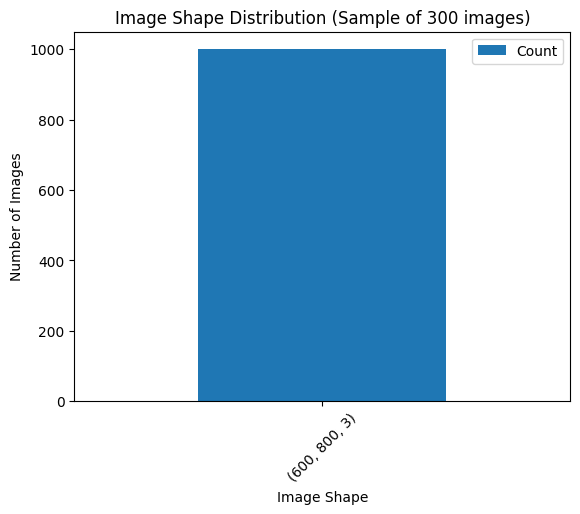

In [28]:
# Plot the image size distribution
img_shapes_df=pd.DataFrame(list(img_shapes.items()),columns=['Image Shape','Count'])
plt.figure(figsize=(10,6))
img_shapes_df.sort_values(by='Count',ascending=False).plot(kind='bar',x='Image Shape')
plt.title('Image Shape Distribution (Sample of 300 images)')
plt.xlabel('Image Shape')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.show()